## PetPals: AI Scope & Future-Proofing

**This notebook bridges the gap between our Supabase backend and data science logic to demonstrate how PetPals can scale beyond CRUD operations into insight-driven care:**

**✅ What It Does**

- Connects directly to live pet activity logs from Supabase

- Parses, groups, and aggregates care routines (feeding, walking, etc.)

- Generates human-readable metrics to monitor behavior trends

- Supports visual insights for pet lifestyle summaries

**🔍 Future AI Expansion**

- Trigger alerts for irregular patterns (e.g., low activity, missed feedings)

- Recommend balanced routines using prompt-based analysis

- Support multi-language summaries for diverse pet owner communities

- Return JSON or API-style results to integrate with front-end dashboards

**♿ AI-Powered Accessibility (Inclusion as a Feature)**

- Simplifies explanations for ESL users and neurodivergent pet parents

- Enables voice-friendly responses via text-to-speech tools

- Offers real-time translation or message adjustment via AI prompts

- Helps users with different cognitive or physical needs engage more naturally with pet care

In [99]:
# imports 
import psycopg2
#import psycopg2.extras

# load environment variables from .env
from dotenv import load_dotenv
# Load environment variables from .env
load_dotenv()


import os # import os to manipualte file paths
import sys # import sys to modify the system path

import json
import pprint

import pandas as pd
import matplotlib.pyplot as plt

# Add the 'scripts' directory to sys.path
sys.path.append(os.path.abspath("../scripts"))

# Load and Analyze CSV Logs
from raw_log_data import parse_raw_pet_data
from pet_health_analysis import analyze_pet_health_and_activity
from pet_insight_script import analyze_csv_logs

In [ ]:
# Fetch variables
USER = os.getenv("user")
PASSWORD = os.getenv("password")
HOST = os.getenv("host")
PORT = os.getenv("port")
DBNAME = os.getenv("dbname")

# Connect to the database
try:
    connection = psycopg2.connect(
        user=USER,
        password=PASSWORD,
        host=HOST,
        port=PORT,
        dbname=DBNAME
    )
    print("Connection successful!")

    # Create cursor to execute SQL queries
    cursor = connection.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    # Example query to fetch data from a selected table
    cursor.execute('SELECT * FROM "Pet_to_Activity";')
    rows = cursor.fetchall()
    # Print the fetched ros in a formatted JSON style
    print(json.dumps(rows, indent=2, default=str))

except Exception as e:
    print(f"Failed to connect: {e}")


Connection successful!
[
  {
    "id": 4,
    "petId": 3,
    "activity": "walking",
    "frequency": 2,
    "date": "2025-06-24 10:40:32"
  },
  {
    "id": 7,
    "petId": 3,
    "activity": "feeding",
    "frequency": 3,
    "date": "2025-06-29 14:30:00"
  },
  {
    "id": 9,
    "petId": 3,
    "activity": "feeding",
    "frequency": 7,
    "date": "2025-06-29 14:30:00"
  },
  {
    "id": 10,
    "petId": 3,
    "activity": "feeding",
    "frequency": 7,
    "date": "2025-07-25 14:30:00"
  },
  {
    "id": 11,
    "petId": 4,
    "activity": "daycare",
    "frequency": 2,
    "date": "2025-06-11 21:50:43"
  },
  {
    "id": 12,
    "petId": 4,
    "activity": "feeding",
    "frequency": 3,
    "date": "2025-06-13 21:51:01"
  },
  {
    "id": 13,
    "petId": 4,
    "activity": "playtime",
    "frequency": 3,
    "date": "2025-06-23 21:51:27"
  }
]


In [29]:
pet_active_df = pd.DataFrame(rows)
pet_active_df.head()


,id,petId,activity,frequency,date
0,4,3,walking,2,2025-06-24 10:40:32
1,7,3,feeding,3,2025-06-29 14:30:00
2,9,3,feeding,7,2025-06-29 14:30:00
3,10,3,feeding,7,2025-07-25 14:30:00
4,11,4,daycare,2,2025-06-11 21:50:43


In [43]:
# Total Activities per Pet
pet_active_df_count = pet_active_df.groupby("petId")["activity"].count().reset_index(name='activity_count')
pet_active_df_count

,petId,activity_count
0,3,4
1,4,3


In [56]:
# Activity Frequency Summary
pet_active_df_sum = pet_active_df.groupby(["petId", "activity"])["frequency"].sum().unstack(fill_value=0).reset_index()
pet_active_df_sum

activity,petId,daycare,feeding,playtime,walking
0,3,0,17,0,2
1,4,2,3,3,0


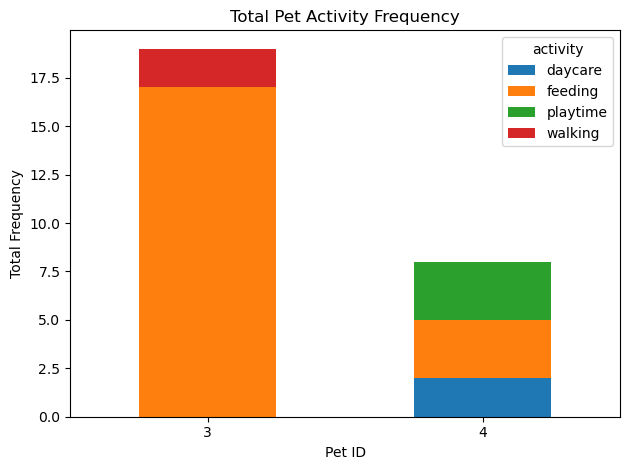

In [36]:
# Pet Activity Frequency Plot 
pet_active_df_sum.plot(kind='bar', stacked=True)
plt.title("Total Pet Activity Frequency")
plt.ylabel("Total Frequency")
plt.xlabel("Pet ID")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [42]:
# Most Logged Activity Overall
activity_count = pet_active_df["activity"].value_counts().reset_index()
activity_count


,activity,count
0,feeding,4
1,walking,1
2,daycare,1
3,playtime,1


## 🧪 AI Mockup — Simulated Pet Log Analysis

This section showcases how PetPals can apply AI-driven analysis using mock data, mirroring real-world backend or device integrations.

- CSV files simulate user-submitted logs tracking pet mood, symptoms, and task completion.

- JSON data emulates a structured API response like /api/pet/:id/analysis, designed for AI consumption.

We apply the same metric logic used in live Supabase queries to validate compatibility and demonstrate how insights could scale across different data sources—local or cloud.

### Behavioral Analysis & Trend Detection (AI Module)

**AI Insight Summary (CSV Mock Logs)**
This result was generated by processing historical health and task logs from mock CSV files, simulating how PetPals will analyze care routines in the real world.

- 🚨 Detected Patterns:

- ✅ Total Low Mood Days: 3

- ⚠️ Consecutive Low Mood Streak Detected

- 🍚 Missed Feedings: 3 days

- 🐕 Missed Walks: 3 days

These indicators would trigger automated alerts or AI suggestions such as:

  - We noticed a low mood streak. Baki might need more playtime.

  - 3 days of missed meals detected — consider reviewing the feeding schedule.

🧠 How It Fits the AI Scope:

  - This logic forms the core reasoning engine for PetPals AI:

  - Takes structured log data (CSV, JSON, or API)

  - Applies business + behavioral logic

  - Outputs insight-ready summaries for:

  - Dashboards

  - Voice/chat assistants

  - Alert systems



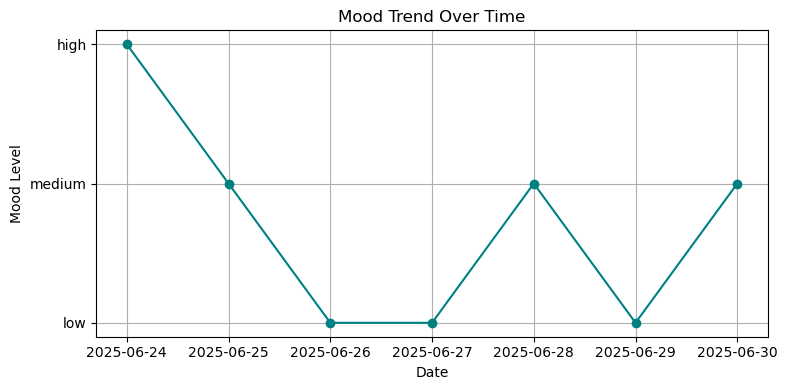

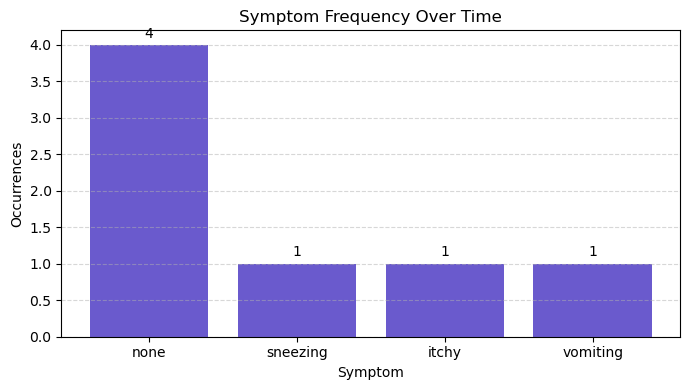

In [98]:
# Load the correct mock health data
df = pd.read_csv("../data/mock_health_logs.csv", parse_dates=["date"])

# --- Mood Trend Over Time ---
mood_map = {"low": 0, "medium": 1, "high": 2}
df["mood_numeric"] = df["mood"].map(mood_map)

plt.figure(figsize=(8, 4))
plt.plot(df["date"], df["mood_numeric"], marker='o', linestyle='-', color='teal')
plt.yticks([0, 1, 2], ["low", "medium", "high"])
plt.title("Mood Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Mood Level")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Symptom Frequency ---
symptom_counts = df["symptoms"].value_counts()
plt.figure(figsize=(7, 4))
bars = plt.bar(symptom_counts.index, symptom_counts.values, color="slateblue")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center')

plt.title("Symptom Frequency Over Time")
plt.xlabel("Symptom")
plt.ylabel("Occurrences")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
